# **Installing Dependencies**
---

In [ ]:
%%capture
!pip install unsloth
!pip install --upgrade --no-cache-dir "git+https://github.com/unslothai/unsloth.git"

# **Mount Google Drive**
---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Finetuning LLM: Summary + Urgency Score**
---

## **Importing Libraries**

In [ ]:
import os
import re
import csv
import json
import glob
import shutil
import time

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from unsloth import FastLanguageModel
from datasets import Dataset
from trl import SFTTrainer
from transformers import TrainingArguments

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## **Declaring Variables**

In [ ]:
# --- Paths ---
BASE_DRIVE_DIR = "/content/drive/MyDrive/LLM Finetuning"
EVAL_CSV_PATH = f"{BASE_DRIVE_DIR}/data/held_out_eval_completed.csv"
TRAINING_DATA_PATH = f"{BASE_DRIVE_DIR}/data/training_data.jsonl"
MERGED_MODEL_DIR = f"{BASE_DRIVE_DIR}/email_digest_model"           # full-precision merged model
GGUF_OUTPUT_DIR = f"{BASE_DRIVE_DIR}/email_digest_model_gguf"       # quantized export directory

# --- Model ---
BASE_MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
MAX_SEQ_LENGTH = 2048

# --- LoRA ---
LORA_R = 16
LORA_ALPHA = 16
LORA_DROPOUT = 0
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj",
                       "gate_proj", "up_proj", "down_proj"]

# --- Training ---
TRAIN_BATCH_SIZE = 2
GRAD_ACCUMULATION_STEPS = 4  # effective batch size = 8

NUM_TRAIN_EPOCHS = 3
LEARNING_RATE = 1e-4
WARMUP_STEPS = 10

# --- Quantization ---
QUANTIZATION_METHOD = "q4_k_m"

# --- Digest filtering (matches app/config.py) ---
URGENCY_THRESHOLD = 3

## **Shared Helper Functions**
The prompt below matches `app/summarizer.py`'s `build_prompt`

In [ ]:
def build_prompt(body: str) -> str:
    """Standalone copy matching app/summarizer.py's build_prompt — kept
    independent of the project package so this notebook has no
    external dependency."""
    return f"""Read this email body and return a JSON object with:
- summary: a one-line summary of the email
- urgency_score: an integer from 1 to 5 rating how much timely action this email requires from the recipient:
  1 = no action needed (newsletters, receipts, FYI notices)
  2 = minor/optional action, no real deadline (casual invites, low-priority updates)
  3 = action expected but not time-critical (routine requests, non-urgent replies)
  4 = action needed soon (upcoming bill due, meeting confirmation, moderate deadline)
  5 = immediate action required (OTP/login codes, account security alerts, bills due imminently, someone actively waiting on a reply)

Base the score only on what's stated in the email. Do not guess or invent details that are not there.

Respond ONLY with a single valid JSON object, in this exact format:
{{"summary": "...", "urgency_score": 3}}

Body: {body}
"""

def strip_json_fences(raw_text: str) -> str:
    """Removes a leading/trailing ```` ```/```json ```` code fence, if present."""
    cleaned = raw_text.strip()
    if cleaned.startswith("```"):
        cleaned = cleaned.split("```")[1]
        if cleaned.startswith("json"):
            cleaned = cleaned[4:]
    return cleaned.strip()


def extract_json_object(text: str) -> str:
    """Pulls out the first {...} block, in case the model added extra prose."""
    match = re.search(r"\{.*\}", text, re.DOTALL)
    return match.group(0) if match else text


def load_eval_rows(csv_path: str) -> list[dict]:
    """Loads the held-out evaluation set. Expects columns: subject,
    sender, date, body, urgency_score, summary (ground truth)."""
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        rows = list(reader)

    parsed = []
    for row in rows:
        if not row.get("body", "").strip():
            continue
        parsed.append({
            "body": row["body"],
            "subject": row.get("subject", ""),
            "true_urgency_score": int(row.get("urgency_score", 1) or 1),
            "true_summary": row.get("summary", ""),
        })
    return parsed


def generate_answer(model, tokenizer, prompt: str, max_new_tokens: int = 200) -> str:
    """Runs one prompt through the given model and returns only the
    newly generated text (prompt tokens excluded), trimmed to the
    first complete JSON object found."""
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        use_cache=True,
        eos_token_id=tokenizer.eos_token_id,
        temperature=0.1,
    )
    raw_output = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    match = re.search(r"\{.*?\}", raw_output, re.DOTALL)
    return match.group(0) if match else raw_output


def run_model_on_rows(model, tokenizer, rows: list[dict], model_label: str) -> list[dict]:
    """Runs inference for every row and returns predictions alongside
    the ground truth already present in each row."""
    FastLanguageModel.for_inference(model)
    results = []

    for i, row in enumerate(rows):
        print(f"[{model_label}] {i + 1}/{len(rows)}: {row['subject'][:50]}")

        prompt = build_prompt(row["body"])
        decoded = generate_answer(model, tokenizer, prompt)

        record = dict(row)
        record["model"] = model_label
        record["raw_output"] = decoded

        try:
            cleaned = extract_json_object(strip_json_fences(decoded))
            parsed = json.loads(cleaned)
            record["pred_summary"] = parsed.get("summary", "")
            record["pred_urgency_score"] = int(parsed.get("urgency_score", 1))
            record["parse_error"] = ""
        except Exception as e:
            record["pred_summary"] = ""
            record["pred_urgency_score"] = None
            record["parse_error"] = str(e)

        results.append(record)

    return results


def run_gguf_on_rows(llm, rows: list[dict], model_label: str) -> list[dict]:
    """Same as run_model_on_rows, but for a quantized GGUF model
    loaded via llama-cpp-python instead of the in-memory transformers
    model."""
    results = []
    for i, row in enumerate(rows):
        print(f"[{model_label}] {i + 1}/{len(rows)}: {row['subject'][:50]}")

        prompt = build_prompt(row["body"])
        response = llm.create_chat_completion(
            messages=[{"role": "user", "content": prompt}],
            max_tokens=200,
            temperature=0.1,
        )
        decoded = response["choices"][0]["message"]["content"]

        record = dict(row)
        record["model"] = model_label
        record["raw_output"] = decoded

        try:
            cleaned = extract_json_object(strip_json_fences(decoded))
            parsed = json.loads(cleaned)
            record["pred_summary"] = parsed.get("summary", "")
            record["pred_urgency_score"] = int(parsed.get("urgency_score", 1))
            record["parse_error"] = ""
        except Exception as e:
            record["pred_summary"] = ""
            record["pred_urgency_score"] = None
            record["parse_error"] = str(e)

        results.append(record)

    return results


def compute_metrics(df: pd.DataFrame, label: str) -> dict:
    """Quantitative metrics only cover urgency_score, since it's the
    numeric/ordinal field with real ground truth to compare against.
    summary is compared qualitatively (side by side in the saved CSV),
    not scored automatically."""
    valid = df[df["parse_error"] == ""]
    parse_success_rate = len(valid) / len(df) if len(df) else 0

    urgency_exact = (valid["pred_urgency_score"] == valid["true_urgency_score"]).mean() if len(valid) else float("nan")
    urgency_mae = (valid["pred_urgency_score"] - valid["true_urgency_score"]).abs().mean() if len(valid) else float("nan")

    return {
        "model": label,
        "parse_success_rate": parse_success_rate,
        "urgency_score_exact_match": urgency_exact,
        "urgency_score_mae": urgency_mae,
    }


def resolve_gguf_path(gguf_dir: str) -> str:
    """Finds the single .gguf file produced by save_pretrained_gguf().

    Call this exactly ONCE, right after export, and reuse the returned path
    everywhere downstream (stored in GGUF_MODEL_PATH). Re-globbing the
    directory later risks silently picking a different file if the folder
    ever ends up containing more than one .gguf.
    """
    matches = glob.glob(f"{gguf_dir}/*.gguf")
    if not matches:
        raise FileNotFoundError(
            f"No .gguf file found in '{gguf_dir}'. Run the GGUF export "
            "cell before trying to load the quantized model."
        )
    return matches[0]


print("Helper functions defined.")

Helper functions defined.


## **Load Held-Out Evaluation Data**
These rows are NOT be part of `training_data.jsonl` — they measure real generalization, not memorization.

In [ ]:
# Ground-truth rows the model is scored against — never seen during training.
eval_rows = load_eval_rows(EVAL_CSV_PATH)
print(f"Loaded {len(eval_rows)} held-out evaluation rows")

Loaded 27 held-out evaluation rows


## **Loading Base Model**

In [ ]:
# 4-bit quantized base checkpoint
print("Loading base model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

Loading base model...
==((====))==  Unsloth 2026.8.19: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

## **Baseline Evaluation (Before Fine-Tuning)**
True zero-shot baseline.

In [ ]:
# Zero-shot baseline — same eval set, same prompt, no fine-tuning yet.
baseline_results = run_model_on_rows(model, tokenizer, eval_rows, model_label="base-qwen3b")
print(f"\nBaseline evaluation complete — {len(baseline_results)} predictions")

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[base-qwen3b] 1/27: 


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[base-qwen3b] 2/27: 


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[base-qwen3b] 25/27: 


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[base-qwen3b] 26/27: 


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[base-qwen3b] 27/27: 

Baseline evaluation complete — 27 predictions


## **Adding LoRA Adapters**

In [ ]:
# Wrap the base model with trainable LoRA adapters (base weights stay frozen).
print("Adding LoRA adapters...")
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=LORA_TARGET_MODULES,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

Adding LoRA adapters...


Unsloth 2026.8.19 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


## **Loading Training Data**

In [ ]:
print("Loading training data...")
training_examples = []
with open(TRAINING_DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        training_examples.append(json.loads(line))
print(f"Loaded {len(training_examples)} training examples")

# Quick data-quality gate — catch empty/missing required fields BEFORE
# spending Colab time training on them.
REQUIRED_KEYS = ["summary", "urgency_score"]
problems = 0
for i, example in enumerate(training_examples):
    completion = json.loads(example["messages"][1]["content"])
    missing = [k for k in REQUIRED_KEYS if k not in completion]
    empty = [k for k, v in completion.items() if v == "" or v is None]
    if missing or empty:
        problems += 1
        print(f"Row {i}: missing={missing}, empty={empty}")

if problems:
    raise ValueError(f"{problems} training examples have missing/empty required fields — fix the data before training.")
print("Training data passed the quality check — no missing or empty required fields.")

Loading training data...
Loaded 96 training examples
Training data passed the quality check — no missing or empty required fields.


## **Preparing Training Data**

In [ ]:
def format_example(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}


dataset = Dataset.from_list(training_examples)
dataset = dataset.map(format_example)
print(dataset[0]["text"][:500])

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Read this email body and return a JSON object with:
- summary: a one-line summary of the email
- urgency_score: an integer from 1 to 5 rating how much timely action this email requires from the recipient:
  1 = no action needed (newsletters, receipts, FYI notices)
  2 = minor/optional action, no real deadline (casual invites, low-priority updates)
  3 = action expected but not time-


## **Starting Training**

In [ ]:
# Supervised fine-tuning on the LoRA-wrapped model.
print("Starting training...")
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUMULATION_STEPS,
        warmup_steps=WARMUP_STEPS,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        learning_rate=LEARNING_RATE,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir=MERGED_MODEL_DIR,
    ),
)

trainer_stats = trainer.train()
print("Training complete.")

Starting training...


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/96 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 96 | Num Epochs = 3 | Total steps = 36
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,2.948602
2,3.172410
3,2.887503
4,3.080910
5,3.048349
6,2.922759
7,2.665001
8,2.421500
9,2.492280
10,2.593761


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/LLM Finetuning/email_digest_model/checkpoint-36/tokenizer_config.json.


Training complete.


# **Sanity Check**
---

## **Training Example — confirms learning happened at all**

In [ ]:
# Switch to inference mode and compare the model's output on a TRAINING
FastLanguageModel.for_inference(model)

train_index = 1
train_prompt = training_examples[train_index]["messages"][0]["content"]
train_expected = training_examples[train_index]["messages"][1]["content"]
train_actual = generate_answer(model, tokenizer, train_prompt)

print("Expected (from training data):")
print(train_expected)
print("\nActual (model's generation):")
print(train_actual)

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Expected (from training data):
{"summary": "The email discusses the BBC's re-airing of 'Tinker, Tailor, Soldier, Spy' and provides commentary on the film's themes and historical context, including references to recent political events and the film's relevance to modern times.", "urgency_score": 1}

Actual (model's generation):
{"summary": "The author discusses the BBC's re-airing of the classic TV drama 'Tinker, Tailor, Soldier, Spy' and its relevance to modern political issues.", "urgency_score": 1}


## **Held-Out Example — checks generalization to unseen data**

In [ ]:
# Same check, but on a HELD-OUT row — tests generalization, not memorization.
eval_index = 0
eval_row = eval_rows[eval_index]
eval_prompt = build_prompt(eval_row["body"])
eval_expected = {"summary": eval_row["true_summary"], "urgency_score": eval_row["true_urgency_score"]}
eval_actual = generate_answer(model, tokenizer, eval_prompt)

print("Expected (your labels):")
print(json.dumps(eval_expected, indent=2))
print("\nActual (model's generation):")
print(eval_actual)

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Expected (your labels):
{
  "summary": "The email promotes The Gift Lab course, which teaches print-on-demand product selling strategies, including keyword research and micro-niche selection, to help users become successful sellers.",
  "urgency_score": 1
}

Actual (model's generation):
{"summary": "Manjit Baishya is offering a course called The Gift Lab that teaches how to sell print-on-demand products.", "urgency_score": 3}


## **Fine-tuned Model Evaluation (pre-quantization)**

In [ ]:
# Full held-out evaluation of the fine-tuned model, still at full training
# precision (before quantization) — the baseline that quantization gets compared against.
premerge_results = run_model_on_rows(model, tokenizer, eval_rows, model_label="finetuned-pre-quant")
print(f"\nPre-quantization evaluation complete — {len(premerge_results)} predictions")

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[finetuned-pre-quant] 1/27: 


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[finetuned-pre-quant] 2/27: 


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[finetuned-pre-quant] 25/27: 


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[finetuned-pre-quant] 26/27: 


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[finetuned-pre-quant] 27/27: 

Pre-quantization evaluation complete — 27 predictions


# **Exporting Model to GGUF**---

In [ ]:
# Export the fine-tuned model to a quantized GGUF file (for llama.cpp / Ollama).
print("Exporting to GGUF...")
model.save_pretrained_gguf(
    GGUF_OUTPUT_DIR,
    tokenizer,
    quantization_method=QUANTIZATION_METHOD
)

Exporting to GGUF...
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/LLM Finetuning/email_digest_model_gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...



Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [01:19<00:00, 39.63s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [03:16<00:00, 98.48s/it]


Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/LLM Finetuning/email_digest_model_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Installing prebuilt llama.cpp b10472-mix-4b653db (app-b10472-mix-4b653db-linux-x64-cpu.tar.gz) - skipping compilation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/drive/MyDrive/LLM Finetuning/email_digest_model_gguf_gguf/Qwen2.5-3B-Instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 

FileNotFoundError: No .gguf file found in '/content/drive/MyDrive/LLM Finetuning/email_digest_model_gguf'. Run the GGUF export cell before trying to load the quantized model.

In [ ]:
# Resolve the actual exported file path
GGUF_MODEL_PATH = resolve_gguf_path(GGUF_OUTPUT_DIR)
print(f"Done. GGUF file: {GGUF_MODEL_PATH}")

Done. GGUF file: /content/drive/MyDrive/LLM Finetuning/email_digest_model_gguf/Qwen2.5-3B-Instruct.Q4_K_M.gguf


## **Quantized (GGUF) Model Evaluation**

In [ ]:
# CPU build of llama-cpp-python — enough to run the quantized model for evaluation.
!pip install -q llama-cpp-python --prefer-binary --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.9/23.9 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.0 MB/s eta 0:00:00


In [ ]:
# Load the actual quantized artifact that would be deployed — not just the
# in-memory model — so we can measure whether quantization cost any accuracy.
from llama_cpp import Llama

print(f"Loading quantized model from: {GGUF_MODEL_PATH}")
quantized_llm = Llama(model_path=GGUF_MODEL_PATH, n_ctx=MAX_SEQ_LENGTH, verbose=False)

quantized_results = run_gguf_on_rows(quantized_llm, eval_rows, model_label="finetuned-quantized")
print(f"\nQuantized evaluation complete — {len(quantized_results)} predictions")

Loading quantized model from: /content/drive/MyDrive/LLM Finetuning/email_digest_model_gguf/Qwen2.5-3B-Instruct.Q4_K_M.gguf
[finetuned-quantized] 1/27: 
[finetuned-quantized] 2/27: 
[finetuned-quantized] 3/27: 
[finetuned-quantized] 4/27: 
[finetuned-quantized] 5/27: 
[finetuned-quantized] 6/27: 
[finetuned-quantized] 7/27: 
[finetuned-quantized] 8/27: 
[finetuned-quantized] 9/27: 
[finetuned-quantized] 10/27: 
[finetuned-quantized] 11/27: 
[finetuned-quantized] 12/27: 
[finetuned-quantized] 13/27: 
[finetuned-quantized] 14/27: 
[finetuned-quantized] 15/27: 
[finetuned-quantized] 16/27: 
[finetuned-quantized] 17/27: 
[finetuned-quantized] 18/27: 
[finetuned-quantized] 19/27: 
[finetuned-quantized] 20/27: 
[finetuned-quantized] 21/27: 
[finetuned-quantized] 22/27: 
[finetuned-quantized] 23/27: 
[finetuned-quantized] 24/27: 
[finetuned-quantized] 25/27: 
[finetuned-quantized] 26/27: 
[finetuned-quantized] 27/27: 

Quantized evaluation complete — 27 predictions


# **Performance Comparison**
---

In [ ]:
# Bring all three evaluation runs together for a side-by-side comparison.
all_results = {
    "base-qwen3b": baseline_results,
    "finetuned-pre-quant": premerge_results,
    "finetuned-quantized": quantized_results,
}

dfs = {label: pd.DataFrame(res) for label, res in all_results.items()}

metrics_df = pd.DataFrame([compute_metrics(df, label) for label, df in dfs.items()])
print(metrics_df.to_string(index=False))

              model  parse_success_rate  urgency_score_exact_match  urgency_score_mae
        base-qwen3b            0.962963                   0.115385           1.730769
finetuned-pre-quant            0.962963                   0.461538           0.807692
finetuned-quantized            1.000000                   0.370370           0.962963


## **Comparison Graphs**

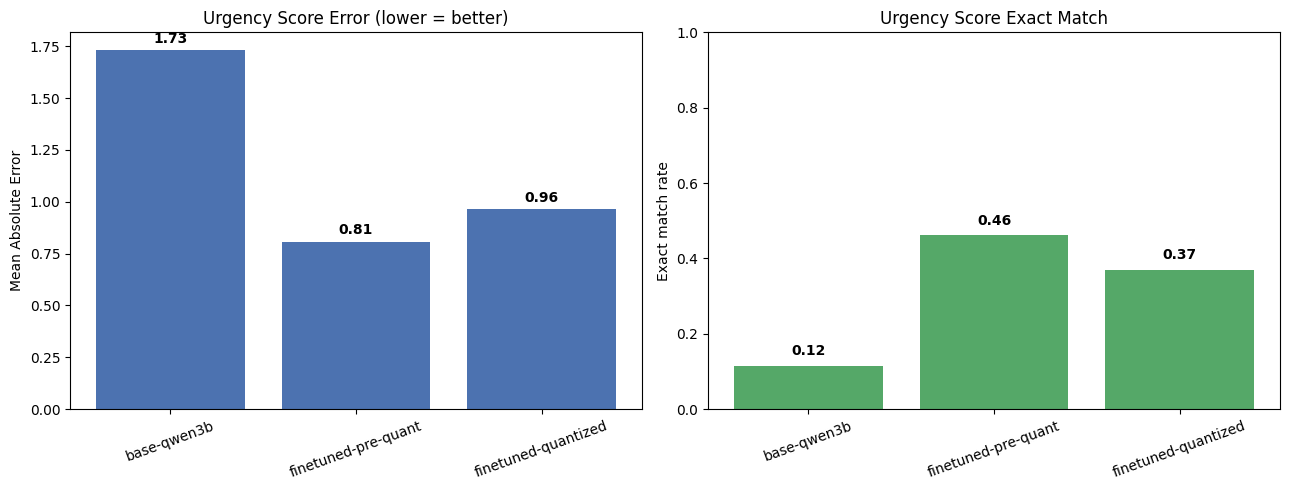

In [ ]:
# Bar charts: urgency-score MAE and exact-match rate, one bar per model.
model_order = list(all_results.keys())
metrics_df_ordered = metrics_df.set_index("model").loc[model_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Urgency score MAE (lower is better) ---
ax = axes[0]
bars = ax.bar(model_order, metrics_df_ordered["urgency_score_mae"], color="#4C72B0")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Urgency Score Error (lower = better)")
ax.tick_params(axis='x', rotation=20)
for bar, value in zip(bars, metrics_df_ordered["urgency_score_mae"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{value:.2f}", ha="center", va="bottom", fontweight="bold")

# --- Urgency score exact-match rate ---
ax = axes[1]
bars = ax.bar(model_order, metrics_df_ordered["urgency_score_exact_match"], color="#55A868")
ax.set_ylim(0, 1)
ax.set_ylabel("Exact match rate")
ax.set_title("Urgency Score Exact Match")
ax.tick_params(axis='x', rotation=20)
for bar, value in zip(bars, metrics_df_ordered["urgency_score_exact_match"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{value:.2f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("urgency_score_comparison.png", dpi=150)
plt.show()

### **Urgency score confusion matrices (predicted vs. your labels)**

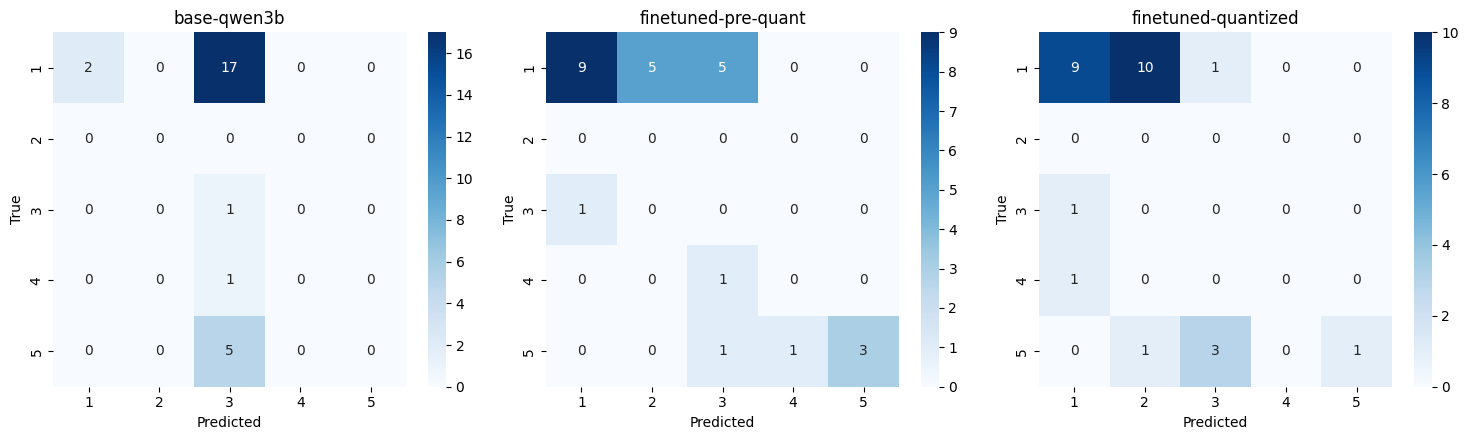

In [ ]:
# Confusion matrix of predicted vs. true urgency score, one heatmap per model.
def urgency_confusion(df: pd.DataFrame):
    valid = df[df["parse_error"] == ""]
    matrix = pd.crosstab(
        valid["true_urgency_score"], valid["pred_urgency_score"],
        rownames=["True"], colnames=["Predicted"]
    ).reindex(index=range(1, 6), columns=range(1, 6), fill_value=0)
    return matrix


n_models = len(model_order)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, label in zip(axes, model_order):
    sns.heatmap(urgency_confusion(dfs[label]), annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(label)

plt.tight_layout()
plt.savefig("urgency_confusion_matrices.png", dpi=150)
plt.show()

## **Save Full Comparison Results**

In [ ]:
# Persist everything for offline review / sharing outside Colab.
combined_df = pd.concat(list(dfs.values()), ignore_index=True)
combined_df.to_csv("all_models_predictions.csv", index=False)
metrics_df.to_csv("all_models_metrics.csv", index=False)

from google.colab import files
files.download("all_models_predictions.csv")
files.download("all_models_metrics.csv")
files.download("urgency_score_comparison.png")
files.download("urgency_confusion_matrices.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Extended Comparison Metrics**
---

## **Summary Quality (ROUGE-L + length + qualitative samples)**
`compute_metrics` only scores `urgency_score`. This adds a text-similarity score for the `summary` field so it isn't left out of the comparison entirely.

In [ ]:
# ROUGE-L scores the free-text `summary` field, which has no single correct answer.
!pip install -q rouge-score

  Preparing metadata (setup.py) ... done


In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def summary_quality(df: pd.DataFrame, label: str) -> dict:
    """Average ROUGE-L F1 and average summary length, over rows that
    parsed successfully and produced a non-empty predicted summary."""
    valid = df[(df["parse_error"] == "") & (df["pred_summary"].str.len() > 0)]

    if len(valid) == 0:
        return {"model": label, "rouge_l_f1": float("nan"), "avg_summary_len_chars": float("nan")}

    scores = [
        scorer.score(row["true_summary"], row["pred_summary"])["rougeL"].fmeasure
        for _, row in valid.iterrows()
    ]

    return {
        "model": label,
        "rouge_l_f1": sum(scores) / len(scores),
        "avg_summary_len_chars": valid["pred_summary"].str.len().mean(),
    }

summary_quality_df = pd.DataFrame([summary_quality(dfs[label], label) for label in model_order])
print(summary_quality_df.to_string(index=False))

              model  rouge_l_f1  avg_summary_len_chars
        base-qwen3b    0.346155              80.846154
finetuned-pre-quant    0.441794             114.192308
finetuned-quantized    0.459277             143.481481


In [ ]:
# Qualitative side-by-side: same held-out row, every model's summary.
sample_idx = 0
sample_body = eval_rows[sample_idx]["body"]
sample_true = eval_rows[sample_idx]["true_summary"]

print(f"EMAIL BODY:\n{sample_body[:300]}\n")
print(f"TRUE SUMMARY:\n{sample_true}\n")
print("-" * 60)

for label in model_order:
    row = dfs[label].iloc[sample_idx]
    print(f"[{label}]")
    print(f"  Predicted: {row['pred_summary']!r}")
    print(f"  Urgency:   true={row['true_urgency_score']}  pred={row['pred_urgency_score']}")
    print()

EMAIL BODY:
This strategy could change everything Manjit Baishya... we've been doing this for a long time. Over 7 years. And in that time, we noticed Etsy was: * focusing more and more on giftable products * encouraging sellers to use gifting keywords such as gifts for her, hostess gifts, and gifts for coworker

TRUE SUMMARY:
The email promotes The Gift Lab course, which teaches print-on-demand product selling strategies, including keyword research and micro-niche selection, to help users become successful sellers.

------------------------------------------------------------
[base-qwen3b]
  Predicted: 'Manjit Baishya is offering a course called The Gift Lab to help print-on-demand sellers increase their sales.'
  Urgency:   true=1  pred=3.0

[finetuned-pre-quant]
  Predicted: 'Manjit Baishya is offering a course called The Gift Lab that teaches how to sell print-on-demand products.'
  Urgency:   true=1  pred=3.0

[finetuned-quantized]
  Predicted: 'The Gift Lab course offers strategie

## **Failure Mode Breakdown**
Parse-error rate is already in `compute_metrics`, but this breaks it down further: which rows fail, and whether errors are biased in a direction (e.g. a model that systematically under-scores urgency).

In [ ]:
def failure_breakdown(df: pd.DataFrame, label: str) -> dict:
    """Parse-failure rate plus mean signed urgency error (which direction
    a model tends to be wrong in, not just how often)."""
    total = len(df)
    failed = df[df["parse_error"] != ""]
    valid = df[df["parse_error"] == ""]

    signed_error = (valid["pred_urgency_score"] - valid["true_urgency_score"]).mean() if len(valid) else float("nan")

    return {
        "model": label,
        "n_total": total,
        "n_parse_failures": len(failed),
        "parse_failure_rate": len(failed) / total if total else float("nan"),
        # positive = over-predicts urgency on average, negative = under-predicts
        "mean_signed_error": signed_error,
    }

failure_df = pd.DataFrame([failure_breakdown(dfs[label], label) for label in model_order])
print(failure_df.to_string(index=False))

              model  n_total  n_parse_failures  parse_failure_rate  mean_signed_error
        base-qwen3b       27                 1            0.037037           0.884615
finetuned-pre-quant       27                 1            0.037037           0.346154
finetuned-quantized       27                 0            0.000000          -0.074074


In [ ]:
# Worst-N rows per model (largest absolute urgency error) — useful for
# spotting whether errors cluster around specific email types.
N_WORST = 5

for label in model_order:
    df = dfs[label]
    valid = df[df["parse_error"] == ""].copy()
    valid["abs_error"] = (valid["pred_urgency_score"] - valid["true_urgency_score"]).abs()
    worst = valid.sort_values("abs_error", ascending=False).head(N_WORST)

    print(f"=== {label}: {N_WORST} worst predictions ===")
    print(worst[["subject", "true_urgency_score", "pred_urgency_score", "abs_error"]].to_string(index=False))
    print()

=== base-qwen3b: 5 worst predictions ===
subject  true_urgency_score  pred_urgency_score  abs_error
                          1                 3.0        2.0
                          1                 3.0        2.0
                          1                 3.0        2.0
                          1                 3.0        2.0
                          1                 3.0        2.0

=== finetuned-pre-quant: 5 worst predictions ===
subject  true_urgency_score  pred_urgency_score  abs_error
                          1                 3.0        2.0
                          1                 3.0        2.0
                          3                 1.0        2.0
                          1                 3.0        2.0
                          1                 3.0        2.0

=== finetuned-quantized: 5 worst predictions ===
subject  true_urgency_score  pred_urgency_score  abs_error
                          5                   2          3
                          4      

## **Latency & Model Size Comparison**
Measures the actual speed/quality tradeoff of quantizing — the usual point of exporting to GGUF in the first place. Timed on a subset of held-out rows to keep this cell fast; increase `N_TIMING_ROWS` for a tighter estimate.

**Note:** the pure base model (before LoRA) is no longer available as a separate object at this point in the notebook — `model` was overwritten in-place by `get_peft_model`. If you want base-model latency too, add a timing loop right after cell "Baseline Evaluation" (before adapters are added), or reload it with `FastLanguageModel.from_pretrained` (costs extra time/memory).

In [ ]:
N_TIMING_ROWS = 10
timing_rows = eval_rows[:N_TIMING_ROWS]

def time_inmemory_model(model, tokenizer, rows, label):
    """Average per-row latency for the full-precision, in-memory model."""
    FastLanguageModel.for_inference(model)
    times = []
    for row in rows:
        prompt = build_prompt(row["body"])
        start = time.perf_counter()
        generate_answer(model, tokenizer, prompt)
        times.append(time.perf_counter() - start)
    return {"model": label, "avg_latency_sec": sum(times) / len(times)}

def time_gguf_model(llm, rows, label):
    """Average per-row latency for the quantized GGUF model via llama.cpp."""
    times = []
    for row in rows:
        prompt = build_prompt(row["body"])
        start = time.perf_counter()
        llm.create_chat_completion(messages=[{"role": "user", "content": prompt}], max_tokens=200, temperature=0.1)
        times.append(time.perf_counter() - start)
    return {"model": label, "avg_latency_sec": sum(times) / len(times)}

latency_results = [
    time_inmemory_model(model, tokenizer, timing_rows, "finetuned-pre-quant"),
    time_gguf_model(quantized_llm, timing_rows, "finetuned-quantized"),
]
latency_df = pd.DataFrame(latency_results)
print(latency_df.to_string(index=False))

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

              model  avg_latency_sec
finetuned-pre-quant        22.524216
finetuned-quantized        60.909508


In [ ]:
def dir_size_mb(path):
    """Total size in MB of every file under a directory (recursively)."""
    if not os.path.isdir(path):
        return float("nan")
    total = sum(os.path.getsize(os.path.join(dp, f)) for dp, _, fs in os.walk(path) for f in fs)
    return total / (1024 ** 2)

def file_size_mb(path):
    """Size in MB of a single file."""
    return os.path.getsize(path) / (1024 ** 2) if os.path.isfile(path) else float("nan")

# Reuse the constant resolved once in the GGUF export cell — no re-globbing here.
merged_size_mb = dir_size_mb(MERGED_MODEL_DIR)
gguf_size_mb = file_size_mb(GGUF_MODEL_PATH)

print(f"Merged (full-precision) model: {merged_size_mb:.1f} MB")
print(f"Quantized GGUF model:          {gguf_size_mb:.1f} MB")
print(f"Size reduction:                {(1 - gguf_size_mb / merged_size_mb) * 100:.1f}%")

Merged (full-precision) model: 5896.9 MB
Quantized GGUF model:          1840.5 MB
Size reduction:                68.8%
